<a href="https://colab.research.google.com/github/VatsalNilay/hindi-fluency-experiment-data-analysis/blob/main/report1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import json
import csv
import os
from collections import defaultdict
import pandas as pd
from IPython.display import display, FileLink

OUTPUT_DIR = "/content/extracted_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILE_PATH = "/content/responses.json"


In [50]:
# ## 2. Helper Functions

def safe_json_parse(s):
    if isinstance(s, str):
        try:
            return json.loads(s)
        except Exception:
            return None
    return s


def load_data(file_path):
    """Load and return the top-level subjects dict from the JSON file."""
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    subjects_data = data.get("fluency-spam", {})
    print(f"Loaded file: {file_path}")
    print(f"Found {len(subjects_data)} subjects.\n")
    return subjects_data


def flatten_trial(trial):
    """Flatten a trial dict, merging nested 'response' keys into the top level."""
    items = {}
    for k, v in trial.items():
        if k == "response" and isinstance(v, dict):
            for rk, rv in v.items():
                items[rk] = rv
        elif k != "response":
            items[k] = v

    resp = trial.get("response")
    if isinstance(resp, str):
        parsed = safe_json_parse(resp)
        if isinstance(parsed, dict):
            for rk, rv in parsed.items():
                items[rk] = rv

    return items



In [51]:
# ## 3. Extraction Functions

# %%
def extract_vft(subject_id, trials):
    """Return a list of VFT row dicts for one subject."""
    rows = []
    for trial in trials:
        if trial.get("task") != "VFT":
            continue
        domain = trial.get("domain", "unknown")
        is_practice = "practice" in domain.lower()
        tagged = safe_json_parse(trial.get("tagged_responses"))
        times  = safe_json_parse(trial.get("response_times"))
        if tagged and times and len(tagged) == len(times):
            for idx, item in enumerate(tagged):
                word_raw = item.get("response", "").strip()
                position = item.get("tag", idx + 1)
                irt = float(times[idx]) if times[idx] is not None else None
                rows.append({
                    "subject_id":     subject_id,
                    "domain":         domain,
                    "word_raw":       word_raw,
                    "word_canonical": "",
                    "position":       position,
                    "IRT_ms":         irt,
                    "is_practice":    is_practice,
                    "cluster_label":  ""
                })
    return rows


def extract_spam(subject_id, trials):
    """Return a list of SpAM row dicts for one subject (last placement per word)."""
    spam_last = defaultdict(dict)
    for trial in trials:
        if trial.get("task") != "SpAM":
            continue
        domain = trial.get("domain", "unknown")
        is_practice = "practice" in domain.lower()
        for entry in trial.get("droppedwords", []):
            word_id = entry.get("id")
            if word_id:
                spam_last[(domain, word_id)] = {
                    "subject_id":     subject_id,
                    "domain":         domain,
                    "word_raw":       entry.get("word", "").strip(),
                    "word_canonical": "",
                    "x_norm":         entry.get("x_norm"),
                    "y_norm":         entry.get("y_norm"),
                    "is_practice":    is_practice
                }
    return list(spam_last.values())


def extract_demographics(subject_id, subject_raw):
    """Return a demographics row dict for one subject."""
    demo_row = {"subject_id": subject_id}

    # first_language
    first_lang = subject_raw.get("first_language", "")
    demo_row["first_language"] = first_lang

    # L1_hindi
    l1_hindi = ""
    for key in ["L1_hindi", "hindi_native", "hindi_first"]:
        if key in subject_raw and subject_raw[key]:
            l1_hindi = subject_raw[key]
            break
    if not l1_hindi and first_lang:
        l1_hindi = "Yes" if first_lang.lower() == "hindi" else "No"
    demo_row["L1_hindi"] = l1_hindi

    # language_count
    demo_row["language_count"] = subject_raw.get("language_count", "")

    # languages_list
    lang_list = subject_raw.get("languages_list")
    if lang_list is None:
        lang_buffer = subject_raw.get("languages_buffer", "")
        if lang_buffer:
            lang_list = lang_buffer.split("||") if "||" in lang_buffer else [x.strip() for x in lang_buffer.split(",")]
        else:
            lang_list = []
    if isinstance(lang_list, list):
        lang_list = [l.strip() for l in lang_list if l.strip()]
        lang_list_str = ", ".join(lang_list)
    else:
        lang_list_str = ""
    demo_row["languages_list"] = lang_list_str

    # Hindi / English fluency
    demo_row["hindi_read_fluency"]   = subject_raw.get("Hi_Read", "")
    demo_row["hindi_write_fluency"]  = subject_raw.get("Hi_Write", "")
    demo_row["english_read_fluency"] = subject_raw.get("En_Read", "")
    demo_row["english_write_fluency"]= subject_raw.get("En_Write", "")

    # hindi_confidence
    hindi_conf = ""
    lang_conf = subject_raw.get("language_confidence")
    if isinstance(lang_conf, dict):
        for lang, val in lang_conf.items():
            if lang.lower() == "hindi":
                hindi_conf = val
                break
    else:
        if lang_list_str:
            langs = [l.strip() for l in lang_list_str.split(",")]
            conf_vals = {}
            i = 0
            while f"confidence_{i}" in subject_raw:
                conf_vals[i] = subject_raw[f"confidence_{i}"]
                i += 1
            if conf_vals and langs:
                try:
                    hindi_idx = next(i for i, lang in enumerate(langs) if lang.lower() == "hindi")
                    hindi_conf = conf_vals.get(hindi_idx, "")
                except StopIteration:
                    pass
    demo_row["hindi_confidence"] = hindi_conf

    # hindi_acquisition
    hindi_acq = ""
    lang_acq = subject_raw.get("language_acquisition")
    if isinstance(lang_acq, dict):
        for lang, val in lang_acq.items():
            if lang.lower() == "hindi":
                hindi_acq = val
                break
    else:
        if lang_list_str:
            langs = [l.strip() for l in lang_list_str.split(",")]
            acq_vals = {}
            i = 0
            while f"acquisition_{i}" in subject_raw:
                acq_vals[i] = subject_raw[f"acquisition_{i}"]
                i += 1
            if acq_vals and langs:
                try:
                    hindi_idx = next(i for i, lang in enumerate(langs) if lang.lower() == "hindi")
                    hindi_acq = acq_vals.get(hindi_idx, "")
                except StopIteration:
                    pass
    demo_row["hindi_acquisition"] = hindi_acq

    # Remaining fields
    demo_row["age"]           = subject_raw.get("age", "")
    demo_row["gender"]        = subject_raw.get("gender", "")
    demo_row["education"]     = subject_raw.get("education", "") or subject_raw.get("edu", "")
    demo_row["state_ut"]      = subject_raw.get("state_ut", "") or subject_raw.get("state", "")
    demo_row["dominant_hand"] = subject_raw.get("dominant_hand", "")
    demo_row["alert_time"]    = subject_raw.get("alert_time", "")
    demo_row["strategies"]    = subject_raw.get("strategies", "")
    demo_row["additional_info"] = subject_raw.get("additional_info", "") or subject_raw.get("other_info", "")

    return demo_row


In [52]:
## 4. Process All Subjects

# %%
def process_subjects(subjects_data):
    """Iterate over all subjects and collect VFT, SpAM, and demographics rows."""
    vft_rows, spam_rows, demo_rows = [], [], []

    for subject_key, subject_content in subjects_data.items():
        subject_id = subject_content.get("subject_id", subject_key)
        trials = subject_content.get("data", [])

        # Build a flat subject_raw dict from all trials
        subject_raw = {}
        for trial in trials:
            subject_raw.update(flatten_trial(trial))

        vft_rows.extend(extract_vft(subject_id, trials))
        spam_rows.extend(extract_spam(subject_id, trials))
        demo_rows.append(extract_demographics(subject_id, subject_raw))

    return vft_rows, spam_rows, demo_rows


In [53]:
# ## 5. Save to CSV

# %%
def save_csv(rows, filepath, fieldnames):
    """Write a list of dicts to a CSV file."""
    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def save_all(vft_rows, spam_rows, demo_rows, output_dir):
    """Save all three tables and return their file paths."""
    vft_csv  = os.path.join(output_dir, "vft_raw.csv")
    spam_csv = os.path.join(output_dir, "spam_raw.csv")
    demo_csv = os.path.join(output_dir, "demographics_raw.csv")

    save_csv(vft_rows, vft_csv, [
        "subject_id", "domain", "word_raw", "word_canonical",
        "position", "IRT_ms", "is_practice", "cluster_label"
    ])
    save_csv(spam_rows, spam_csv, [
        "subject_id", "domain", "word_raw", "word_canonical",
        "x_norm", "y_norm", "is_practice"
    ])
    save_csv(demo_rows, demo_csv, [
        "subject_id", "first_language", "L1_hindi", "language_count", "languages_list",
        "hindi_read_fluency", "hindi_write_fluency", "english_read_fluency", "english_write_fluency",
        "hindi_confidence", "hindi_acquisition", "age", "gender", "education", "state_ut",
        "dominant_hand", "alert_time", "strategies", "additional_info"
    ])

    return vft_csv, spam_csv, demo_csv



In [54]:
# ## 6. Summary

# %%
def display_summary(vft_rows, spam_rows, demo_rows, vft_csv, spam_csv, demo_csv):
    print(f"\nFiles saved in '{OUTPUT_DIR}':")
    print(f"   - VFT:          {len(vft_rows)} rows  → {vft_csv}")
    print(f"   - SpAM:         {len(spam_rows)} rows  → {spam_csv}")
    print(f"   - Demographics: {len(demo_rows)} rows  → {demo_csv}")

    if vft_rows:
        print("\nSample VFT rows (first 3):")
        display(pd.DataFrame(vft_rows[:3]))
    if spam_rows:
        print("\nSample SpAM rows (first 3):")
        display(pd.DataFrame(spam_rows[:3]))
    if demo_rows:
        print("\nSample demographics rows (first 3):")
        display(pd.DataFrame(demo_rows[:3]))


In [55]:
 ## 7. Final Run for clean data
subjects_data          = load_data(FILE_PATH)
vft_rows, spam_rows, demo_rows = process_subjects(subjects_data)
vft_csv, spam_csv, demo_csv    = save_all(vft_rows, spam_rows, demo_rows, OUTPUT_DIR)
display_summary(vft_rows, spam_rows, demo_rows, vft_csv, spam_csv, demo_csv)

Loaded file: /content/responses.json
Found 35 subjects.


Files saved in '/content/extracted_data':
   - VFT:          1232 rows  → /content/extracted_data/vft_raw.csv
   - SpAM:         1228 rows  → /content/extracted_data/spam_raw.csv
   - Demographics: 35 rows  → /content/extracted_data/demographics_raw.csv

Sample VFT rows (first 3):


,subject_id,domain,word_raw,word_canonical,position,IRT_ms,is_practice,cluster_label
0,10255,furniture-practice,chair,,1,9613.2,True,
1,10255,furniture-practice,sofa,,2,1365.9,True,
2,10255,furniture-practice,bench,,3,1445.4,True,



Sample SpAM rows (first 3):


,subject_id,domain,word_raw,word_canonical,x_norm,y_norm,is_practice
0,10255,furniture-practice,chair,,0.661832,0.929566,True
1,10255,furniture-practice,sofa,,0.498202,0.996904,True
2,10255,furniture-practice,bench,,0.349398,0.989164,True



Sample demographics rows (first 3):


,subject_id,first_language,L1_hindi,language_count,languages_list,hindi_read_fluency,hindi_write_fluency,english_read_fluency,english_write_fluency,hindi_confidence,hindi_acquisition,age,gender,education,state_ut,dominant_hand,alert_time,strategies,additional_info
0,10255,Telugu,No,3,"Telugu, Hindi, English",4,4,5,5,4,2,27,Male,20,Andhra Pradesh,Right,Morning,,no
1,95712,Hindi,Yes,2,"Hindi, English",5,4,5,4,5,1,23,Male,17,Chhattisgarh,Right,No difference,it's based on my liking or based on the sequen...,i am used to type in english but don't have th...
2,53105,Gujarati,No,3,"Gujarati, Hindi, English",5,5,5,5,5,2,21,Male,16,Gujarat,Right,Morning,,


In [56]:

# # Data Cleaning and Preprocessing

# ## 1. Setup and Imports

import numpy as np
import os
from itertools import combinations
from IPython.display import display, FileLink


INPUT_DIR    = "/content/extracted_data"
OUTPUT_DIR   = "/content/cleaned_data"
MAPPING_FILE = os.path.join( "/content", "canonical_mapping_completed.csv")  # completed mapping

VFT_RAW          = os.path.join(INPUT_DIR, "vft_raw.csv")
SPAM_RAW         = os.path.join(INPUT_DIR, "spam_raw.csv")
DEMO_RAW         = os.path.join(INPUT_DIR, "demographics_raw.csv")
MAPPING_TEMPLATE = os.path.join(INPUT_DIR, "canonical_mapping_template.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)



# ## 2. Helper — Generate Mapping Template (run once if needed)

def generate_template():
    """
    Generate a canonical mapping template CSV from the raw VFT file.
    Open the saved file, fill 'word_canonical' and 'cluster_label',
    save it as 'canonical_mapping_completed.csv', then run the pipeline.
    Use '[EXCLUDE]' as the canonical value for garbled / off-category words.
    """
    if not os.path.exists(VFT_RAW):
        print("[Error] Raw VFT file not found. Run the extraction notebook first.")
        return
    vft = pd.read_csv(VFT_RAW)
    unique_words = (
        vft[["domain", "word_raw"]]
        .drop_duplicates()
        .sort_values(["domain", "word_raw"])
    )
    unique_words.to_csv(MAPPING_TEMPLATE, index=False)
    print(f"[OK] Template saved to: {MAPPING_TEMPLATE}")
    print("Fill 'word_canonical' and 'cluster_label' columns, then save as 'canonical_mapping_completed.csv'.")

# generate_template()

# ## 3. Load Raw Data

def load_raw_data():
    """Load and return raw VFT, SpAM, and demographics DataFrames."""
    for path in [VFT_RAW, SPAM_RAW, DEMO_RAW]:
        if not os.path.exists(path):
            raise FileNotFoundError(f"[Error] Required file not found: {path}. Run the extraction notebook first.")

    vft  = pd.read_csv(VFT_RAW)
    spam = pd.read_csv(SPAM_RAW)
    demo = pd.read_csv(DEMO_RAW)

    print("[OK] Raw data loaded.")
    print("\n--- VFT raw (first 3) ---");  display(vft.head(3))
    print("\n--- SpAM raw (first 3) ---"); display(spam.head(3))
    print("\n--- Demographics raw (first 3) ---"); display(demo.head(3))

    return vft, spam, demo



# 4. Exclude Practice Trials & Drop Placeholder Columns

def exclude_practice(vft, spam):
    """Remove practice trials and drop empty placeholder columns."""
    vft  = vft[~vft["is_practice"]].copy()
    spam = spam[~spam["is_practice"]].copy()
    vft.drop(columns=["is_practice"], inplace=True)
    spam.drop(columns=["is_practice"], inplace=True)

    for col in ["word_canonical", "cluster_label"]:
        if col in vft.columns:
            vft.drop(columns=[col], inplace=True)
    if "word_canonical" in spam.columns:
        spam.drop(columns=["word_canonical"], inplace=True)

    print("[OK] Practice trials excluded and placeholder columns dropped.")
    return vft, spam



# 5. Load & Apply Canonical Mapping


def load_mapping(mapping_file):
    """Load the completed canonical mapping CSV and remove excluded entries."""
    if not os.path.exists(mapping_file):
        raise FileNotFoundError(
            f"[Error] Mapping file not found: {mapping_file}\n"
        )
    mapping = pd.read_csv(mapping_file)
    mapping["word_raw"]       = mapping["word_raw"].astype(str).str.strip()
    mapping["word_canonical"] = mapping["word_canonical"].astype(str).str.strip()
    mapping["cluster_label"]  = mapping["cluster_label"].astype(str).str.strip()
    mapping = mapping[
        ~mapping["word_canonical"].isin(["[EXCLUDE]", "", "nan"])
    ].copy()
    print(f"[OK] Mapping loaded: {len(mapping)} entries after excluding [EXCLUDE] rows.")
    print("\n--- Mapping sample (first 5) ---"); display(mapping.head())
    return mapping


def apply_mapping(vft, spam, mapping):
    """Merge canonical mapping into VFT and SpAM DataFrames."""
    vft = vft.merge(
        mapping[["domain", "word_raw", "word_canonical", "cluster_label"]],
        on=["domain", "word_raw"], how="inner"
    )
    spam = spam.merge(
        mapping[["domain", "word_raw", "word_canonical"]],
        on=["domain", "word_raw"], how="inner"
    )
    print(f"[OK] Mapping applied. VFT rows: {len(vft)}, SpAM rows: {len(spam)}")
    print("\n--- VFT after mapping (first 3) ---");  display(vft.head(3))
    print("\n--- SpAM after mapping (first 3) ---"); display(spam.head(3))
    return vft, spam



#6. VFT Cleaning

def remove_vft_duplicates(vft):
    """Remove within-participant duplicate canonical words (keep first occurrence)."""
    vft = vft.sort_values(["subject_id", "domain", "position"])
    dup_mask = vft.duplicated(subset=["subject_id", "domain", "word_canonical"], keep="first")
    duplicates_log = vft[dup_mask].copy()

    if not duplicates_log.empty:
        log_path = os.path.join(OUTPUT_DIR, "vft_duplicates_removed.csv")
        duplicates_log.to_csv(log_path, index=False)
        print(f"[Log] Removed {len(duplicates_log)} duplicate VFT rows → {log_path}")
    else:
        print("[OK] No within-participant duplicates found.")

    return vft[~dup_mask].copy(), duplicates_log


def winsorize_irt(vft):
    """Cap IRT values at the 99th percentile and log affected rows."""
    irt_vals = vft["IRT_ms"].dropna()
    capped_log = pd.DataFrame()

    if len(irt_vals) == 0:
        print("[Warning] No IRT values found.")
        return vft, capped_log

    upper_bound = np.percentile(irt_vals, 99)
    capped_mask = vft["IRT_ms"] > upper_bound
    capped_log  = vft.loc[capped_mask, ["subject_id", "domain", "position", "word_canonical", "IRT_ms"]].copy()
    capped_log["original_IRT"] = capped_log["IRT_ms"]
    capped_log["capped_IRT"]   = upper_bound

    vft = vft.copy()
    vft.loc[capped_mask, "IRT_ms"] = upper_bound

    if not capped_log.empty:
        log_path = os.path.join(OUTPUT_DIR, "irt_capped_log.csv")
        capped_log.to_csv(log_path, index=False)
        print(f"[Log] Capped {len(capped_log)} IRT values above {upper_bound:.2f} ms → {log_path}")
    else:
        print("[OK] No IRT values required capping.")

    return vft, capped_log


def vigilance_check(vft):
    """Warn if any participant produced fewer than 3 words in a domain."""
    words_per_pp = vft.groupby(["subject_id", "domain"]).size().reset_index(name="word_count")
    low_count    = words_per_pp[words_per_pp["word_count"] < 3]

    if not low_count.empty:
        log_path = os.path.join(OUTPUT_DIR, "low_word_count_log.csv")
        low_count.to_csv(log_path, index=False)
        print("[Warning] Participants with <3 words in a domain:"); display(low_count)
    else:
        print("[OK] Vigilance check passed — all participants produced ≥3 words per domain.")

    return low_count


def clean_vft(vft):
    """Run all VFT cleaning steps and return the cleaned DataFrame plus logs."""
    vft, dup_log   = remove_vft_duplicates(vft)
    vft, cap_log   = winsorize_irt(vft)
    low_count_log  = vigilance_check(vft)
    print("\n--- VFT after cleaning (first 3) ---"); display(vft.head(3))
    return vft, dup_log, cap_log, low_count_log



# ## 7. SpAM Pairwise Distances

def compute_spam_distances(spam):
    """Compute pairwise Euclidean distances between words per participant/domain."""
    distances = []
    for (subj, domain), group in spam.groupby(["subject_id", "domain"]):
        words = group["word_canonical"].tolist()
        xs    = group["x_norm"].tolist()
        ys    = group["y_norm"].tolist()
        raw   = group["word_raw"].tolist()
        if len(words) < 2:
            continue
        for i, j in combinations(range(len(words)), 2):
            d = np.sqrt((xs[i] - xs[j])**2 + (ys[i] - ys[j])**2)
            distances.append({
                "subject_id": subj,
                "domain":     domain,
                "word1":      words[i],
                "word2":      words[j],
                "word1_raw":  raw[i],
                "word2_raw":  raw[j],
                "distance":   d
            })

    dist_df = pd.DataFrame(distances)
    print(f"[OK] Computed {len(dist_df)} pairwise distances.")
    if not dist_df.empty:
        print("\n--- Pairwise distances sample (first 5) ---"); display(dist_df.head())
    return dist_df


# ## 8. Save Cleaned Files

def save_cleaned(vft, spam, demo, dist_df, dup_log, cap_log, low_count_log):
    """Save all cleaned DataFrames to OUTPUT_DIR and print download links."""
    vft.to_csv(os.path.join(OUTPUT_DIR, "vft_cleaned.csv"),            index=False)
    spam.to_csv(os.path.join(OUTPUT_DIR, "spam_cleaned.csv"),           index=False)
    demo.to_csv(os.path.join(OUTPUT_DIR, "demographics_cleaned.csv"),   index=False)
    dist_df.to_csv(os.path.join(OUTPUT_DIR, "spam_distances.csv"),      index=False)

    print(f"\n[OK] Cleaning complete. Files saved in '{OUTPUT_DIR}':")
    print("   - vft_cleaned.csv")
    print("   - spam_cleaned.csv")
    print("   - demographics_cleaned.csv")
    print("   - spam_distances.csv")
    if not dup_log.empty:
        print("   - vft_duplicates_removed.csv")
    if not cap_log.empty:
        print("   - irt_capped_log.csv")
    if not low_count_log.empty:
        print("   - low_word_count_log.csv")

    print("\n[Links] Download cleaned files:")
    for fname in ["vft_cleaned.csv", "spam_cleaned.csv", "demographics_cleaned.csv", "spam_distances.csv"]:
        print(FileLink(os.path.join(OUTPUT_DIR, fname)))



# ## 9. Run Full Pipeline

vft, spam, demo          = load_raw_data()
vft, spam                = exclude_practice(vft, spam)
mapping                  = load_mapping(MAPPING_FILE)
vft, spam                = apply_mapping(vft, spam, mapping)
vft, dup_log, cap_log, low_count_log = clean_vft(vft)
dist_df                  = compute_spam_distances(spam)
save_cleaned(vft, spam, demo, dist_df, dup_log, cap_log, low_count_log)

[OK] Raw data loaded.

--- VFT raw (first 3) ---


,subject_id,domain,word_raw,word_canonical,position,IRT_ms,is_practice,cluster_label
0,10255,furniture-practice,chair,NaN,1,9613.2,True,NaN
1,10255,furniture-practice,sofa,NaN,2,1365.9,True,NaN
2,10255,furniture-practice,bench,NaN,3,1445.4,True,NaN



--- SpAM raw (first 3) ---


,subject_id,domain,word_raw,word_canonical,x_norm,y_norm,is_practice
0,10255,furniture-practice,chair,NaN,0.661832,0.929566,True
1,10255,furniture-practice,sofa,NaN,0.498202,0.996904,True
2,10255,furniture-practice,bench,NaN,0.349398,0.989164,True



--- Demographics raw (first 3) ---


...


--- VFT after cleaning (first 3) ---


,subject_id,domain,word_raw,position,IRT_ms,word_canonical,cluster_label
776,3342,animals,कुत्ता,1,8739.3,dog,mammals
777,3342,animals,मछली,2,8200.9,fish,aquatic
778,3342,animals,कछुआ,3,8485.6,turtle,reptiles/amphibians


[OK] Computed 5247 pairwise distances.

--- Pairwise distances sample (first 5) ---


,subject_id,domain,word1,word2,word1_raw,word2_raw,distance
0,3342,animals,dog,fish,कुत्ता,मछली,0.375356
1,3342,animals,dog,turtle,कुत्ता,कछुआ,0.477609
2,3342,animals,dog,lion,कुत्ता,शेर,0.267078
3,3342,animals,dog,snake,कुत्ता,साँप,0.425686
4,3342,animals,dog,dinosaur,कुत्ता,डायनासोर,0.823916



[OK] Cleaning complete. Files saved in '/content/cleaned_data':
   - vft_cleaned.csv
   - spam_cleaned.csv
   - demographics_cleaned.csv
   - spam_distances.csv
   - vft_duplicates_removed.csv
   - irt_capped_log.csv
   - low_word_count_log.csv

[Links] Download cleaned files:
/content/cleaned_data/vft_cleaned.csv
/content/cleaned_data/spam_cleaned.csv
/content/cleaned_data/demographics_cleaned.csv
/content/cleaned_data/spam_distances.csv


In [57]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR  = "/contnet/cleaned_data"
OUTPUT_DIR = "/content/analysis_output"
# ─────────────────────────────────────────────────────────────────────────────

ANALYSIS_FOLDERS = {
    "desc":      "descriptive_analysis",
    "retrieval": "retrieval_time_analysis",
    "cluster":   "cluster_analysis",
    "semantic":  "semantic_space_analysis",
    "fluency":   "fluency_effects",
}
for folder in ANALYSIS_FOLDERS.values():
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

DESC_FOLDER = os.path.join(OUTPUT_DIR, ANALYSIS_FOLDERS["desc"])


In [58]:
# ## Cell 2: Load Cleaned Data

# %%
vft        = pd.read_csv(os.path.join("", "/content/cleaned_data/vft_cleaned.csv"))
spam_dist  = pd.read_csv(os.path.join("", "/content/cleaned_data/spam_distances.csv"))
spam_clean = pd.read_csv(os.path.join("", "/content/cleaned_data/spam_cleaned.csv"))
demo       = pd.read_csv(os.path.join("", "/content/cleaned_data/demographics_cleaned.csv"))

print("[OK] Data loaded.")
print(f"  VFT rows:        {len(vft)}")
print(f"  SpAM dist rows:  {len(spam_dist)}")
print(f"  SpAM clean rows: {len(spam_clean)}")
print(f"  Demo rows:       {len(demo)}")

[OK] Data loaded.
  VFT rows:        1020
  SpAM dist rows:  5247
  SpAM clean rows: 993
  Demo rows:       35


In [59]:
# ## Cell 3: Compute Per-Participant Stats & Descriptive Table

# %%
print("\n" + "="*50)
print("Analysis 1: Descriptive Statistics")
print("="*50)

# Total words and mean IRT per participant per domain
stats1 = vft.groupby(["subject_id", "domain"]).agg(
    total_words=("word_canonical", "count"),
    mean_IRT=("IRT_ms", "mean")
).reset_index()

# Descriptive stats per domain
desc_stats = []
for d in stats1["domain"].unique():
    data             = stats1[stats1["domain"] == d]
    N                = len(data)
    mean_w, sd_w     = data["total_words"].mean(), data["total_words"].std(ddof=1)
    sem_w            = sd_w / np.sqrt(N)
    mean_irt, sd_irt = data["mean_IRT"].mean(), data["mean_IRT"].std(ddof=1)
    sem_irt          = sd_irt / np.sqrt(N)
    desc_stats.append({
        "Domain":        d,
        "N":             N,
        "Mean_words":    mean_w,
        "Median_words":  data["total_words"].median(),
        "Mode_words":    data["total_words"].mode()[0] if not data["total_words"].mode().empty else np.nan,
        "SD_words":      sd_w,
        "Var_words":     data["total_words"].var(ddof=1),
        "IQR_words":     data["total_words"].quantile(0.75) - data["total_words"].quantile(0.25),
        "Range_words":   data["total_words"].max() - data["total_words"].min(),
        "SEM_words":     sem_w,
        "CI_low_words":  mean_w - 1.96 * sem_w,
        "CI_high_words": mean_w + 1.96 * sem_w,
        "Mean_IRT":      mean_irt,
        "SD_IRT":        sd_irt,
        "SEM_IRT":       sem_irt,
        "CI_low_IRT":    mean_irt - 1.96 * sem_irt,
        "CI_high_IRT":   mean_irt + 1.96 * sem_irt,
    })

desc_df = pd.DataFrame(desc_stats)
desc_df.to_csv(os.path.join(DESC_FOLDER, "descriptive_stats.csv"), index=False)

print("\nDescriptive statistics table:")
display(desc_df[["Domain", "N", "Mean_words", "SD_words", "Mean_IRT"]])



Analysis 1: Descriptive Statistics

Descriptive statistics table:


,Domain,N,Mean_words,SD_words,Mean_IRT
0,animals,35,10.257143,4.591186,6230.982375
1,body-parts,24,8.500000,3.007238,7098.317822
2,foods,35,9.028571,4.176163,6934.326573
3,colours,11,12.818182,3.763461,4131.220072


In [60]:
print("\n" + "="*50)
print("Analysis 1: Descriptive Statistics")
print("="*50)

# Total words and mean IRT per participant per domain
stats1 = vft.groupby(["subject_id", "domain"]).agg(
    total_words=("word_canonical", "count"),
    mean_IRT=("IRT_ms", "mean")
).reset_index()

print(f"[OK] Per-participant stats computed: {len(stats1)} rows")
display(stats1.head())

desc_stats = []
for d in stats1["domain"].unique():
    data             = stats1[stats1["domain"] == d]
    N                = len(data)
    mean_w, sd_w     = data["total_words"].mean(), data["total_words"].std(ddof=1)
    sem_w            = sd_w / np.sqrt(N)
    mean_irt, sd_irt = data["mean_IRT"].mean(), data["mean_IRT"].std(ddof=1)
    sem_irt          = sd_irt / np.sqrt(N)
    desc_stats.append({
        "Domain":        d,
        "N":             N,
        "Mean_words":    mean_w,
        "Median_words":  data["total_words"].median(),
        "Mode_words":    data["total_words"].mode()[0] if not data["total_words"].mode().empty else np.nan,
        "SD_words":      sd_w,
        "Var_words":     data["total_words"].var(ddof=1),
        "IQR_words":     data["total_words"].quantile(0.75) - data["total_words"].quantile(0.25),
        "Range_words":   data["total_words"].max() - data["total_words"].min(),
        "SEM_words":     sem_w,
        "CI_low_words":  mean_w - 1.96 * sem_w,
        "CI_high_words": mean_w + 1.96 * sem_w,
        "Mean_IRT":      mean_irt,
        "SD_IRT":        sd_irt,
        "SEM_IRT":       sem_irt,
        "CI_low_IRT":    mean_irt - 1.96 * sem_irt,
        "CI_high_IRT":   mean_irt + 1.96 * sem_irt,
    })

desc_df = pd.DataFrame(desc_stats)

print("\nDescriptive statistics table:")
display(desc_df[["Domain", "N", "Mean_words", "SD_words", "Mean_IRT"]])


desc_df.to_csv(os.path.join(DESC_FOLDER, "descriptive_stats.csv"), index=False)
stats1.to_csv(os.path.join(OUTPUT_DIR, "_stats1_per_participant.csv"), index=False)

print("[OK] descriptive_stats.csv saved in descriptive_analysis/")
print("[OK] _stats1_per_participant.csv saved for use in Part 1b and downstream notebooks.")



Analysis 1: Descriptive Statistics
[OK] Per-participant stats computed: 105 rows


,subject_id,domain,total_words,mean_IRT
0,3342,animals,7,8523.528571
1,3342,body-parts,7,7310.742857
2,3342,foods,7,7980.742857
3,5157,animals,9,5523.800000
4,5157,body-parts,12,4532.016667



Descriptive statistics table:


,Domain,N,Mean_words,SD_words,Mean_IRT
0,animals,35,10.257143,4.591186,6230.982375
1,body-parts,24,8.500000,3.007238,7098.317822
2,foods,35,9.028571,4.176163,6934.326573
3,colours,11,12.818182,3.763461,4131.220072


[OK] descriptive_stats.csv saved in descriptive_analysis/
[OK] _stats1_per_participant.csv saved for use in Part 1b and downstream notebooks.


[OK] Data loaded.
  VFT rows:    1020
  Stats1 rows: 105
  Domains:     ['animals', 'body-parts', 'foods', 'colours']


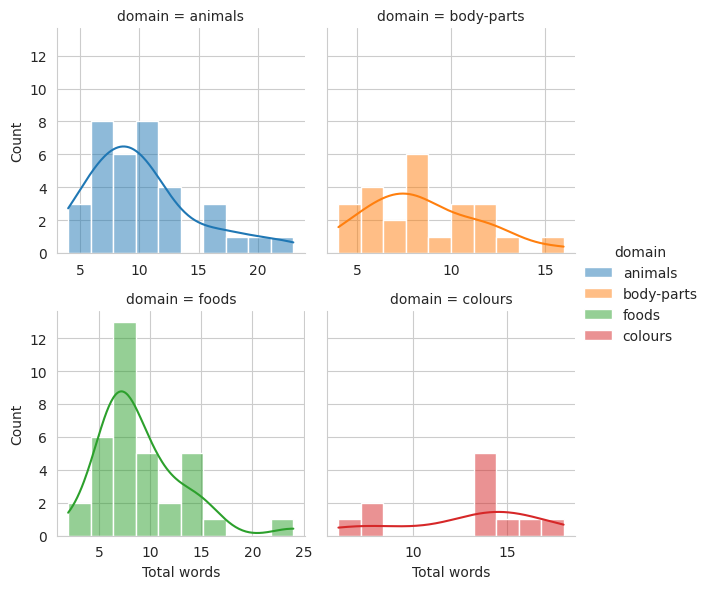

[OK] hist_total_words.png saved.


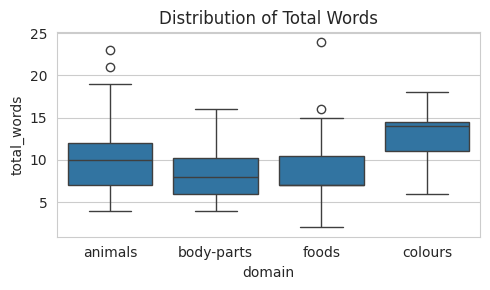

[OK] boxplot_total_words.png saved.


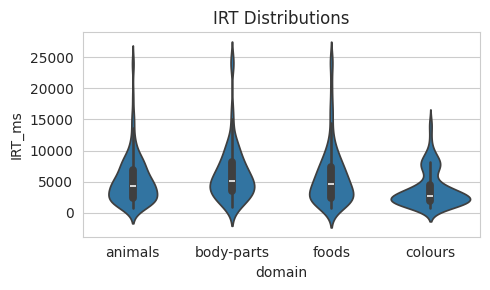

[OK] violin_IRT.png saved.


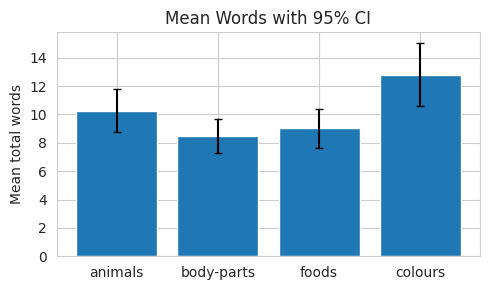

[OK] bar_mean_words_ci.png saved.

[OK] Part 1b complete. All 4 figures saved in descriptive_analysis/


In [61]:

# This cell covers:
#   1. Histogram with KDE of total words per domain
#   2. Box plot of total words across domains
#   3. Violin plot of IRT distributions per domain
#   4. Bar chart with 95% CI for mean words per domain
# Imports & Setup


%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR  = "/content/cleaned_data"
OUTPUT_DIR = "/content/analysis_output"
# ─────────────────────────────────────────────────────────────────────────────

DESC_FOLDER = os.path.join(OUTPUT_DIR, "descriptive_analysis")
os.makedirs(DESC_FOLDER, exist_ok=True)

# Load data
vft     = pd.read_csv(os.path.join(INPUT_DIR, "vft_cleaned.csv"))
stats1  = pd.read_csv(os.path.join(OUTPUT_DIR, "_stats1_per_participant.csv"))
desc_df = pd.read_csv(os.path.join(DESC_FOLDER, "descriptive_stats.csv"))

print("[OK] Data loaded.")
print(f"  VFT rows:    {len(vft)}")
print(f"  Stats1 rows: {len(stats1)}")
print(f"  Domains:     {desc_df['Domain'].tolist()}")

# Histogram with KDE of Total Words per Domain

g = sns.FacetGrid(stats1, col="domain", hue="domain", col_wrap=2, sharex=False, height=3)
g.map(sns.histplot, "total_words", kde=True, bins=10)
g.set_axis_labels("Total words", "Count")
g.add_legend()
plt.savefig(os.path.join(DESC_FOLDER, "hist_total_words.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] hist_total_words.png saved.")

# Figure 2 — Box Plot of Total Words Across Domains

# %%
plt.figure(figsize=(5, 3))
sns.boxplot(data=stats1, x="domain", y="total_words")
plt.title("Distribution of Total Words")
plt.tight_layout()
plt.savefig(os.path.join(DESC_FOLDER, "boxplot_total_words.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] boxplot_total_words.png saved.")


# Figure 3 — Violin Plot of IRT Distributions per Domain

plt.figure(figsize=(5, 3))
sns.violinplot(data=vft, x="domain", y="IRT_ms")
plt.title("IRT Distributions")
plt.tight_layout()
plt.savefig(os.path.join(DESC_FOLDER, "violin_IRT.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] violin_IRT.png saved.")


# Figure 4 — Bar Chart with 95% CI for Mean Words per Domain

plt.figure(figsize=(5, 3))
x = np.arange(len(desc_df))
plt.bar(x, desc_df["Mean_words"], yerr=1.96 * desc_df["SEM_words"],
        capsize=3, tick_label=desc_df["Domain"])
plt.ylabel("Mean total words")
plt.title("Mean Words with 95% CI")
plt.tight_layout()
plt.savefig(os.path.join(DESC_FOLDER, "bar_mean_words_ci.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] bar_mean_words_ci.png saved.")

print("\n[OK] Part 1b complete. All 4 figures saved in descriptive_analysis/")

[OK] VFT loaded: 1020 rows

Analysis 2: IRT over Positions
Regression: IRT = 6949.52 + -285.94 * position
R² = 0.286, p = 0.0734


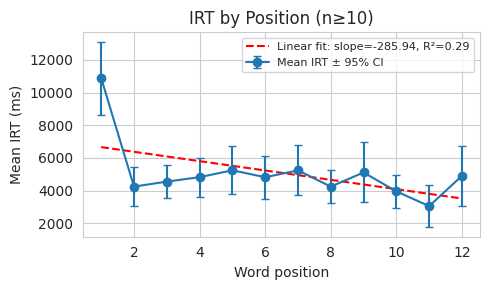

[OK] Figure saved: IRT_by_position.png


In [62]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

INPUT_DIR  = "/content/cleaned_data"
OUTPUT_DIR = "/content/analysis_output"

RETRIEVAL_FOLDER = os.path.join(OUTPUT_DIR, "retrieval_time_analysis")
CLUSTER_FOLDER   = os.path.join(OUTPUT_DIR, "cluster_analysis")
os.makedirs(RETRIEVAL_FOLDER, exist_ok=True)
os.makedirs(CLUSTER_FOLDER,   exist_ok=True)

vft = pd.read_csv(os.path.join(INPUT_DIR, "vft_cleaned.csv"))
print(f"[OK] VFT loaded: {len(vft)} rows")

print("\n" + "="*50)
print("Analysis 2: IRT over Positions")
print("="*50)

# Mean IRT per position per domain (positions with n >= 10 only)
vft_pos = vft.groupby(["domain", "position"]).agg(
    mean_IRT=("IRT_ms", "mean"),
    sem_IRT=("IRT_ms", "sem"),
    n=("IRT_ms", "count")
).reset_index()
vft_pos = vft_pos[vft_pos["n"] >= 10].copy()

# Overall: average across domains at each position
overall_pos = vft_pos.groupby("position").agg(
    mean_IRT=("mean_IRT", "mean"),
    sem_IRT=("sem_IRT", "mean")
).reset_index()

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(
    overall_pos["position"], overall_pos["mean_IRT"]
)
r2 = r_value ** 2
print(f"Regression: IRT = {intercept:.2f} + {slope:.2f} * position")
print(f"R² = {r2:.3f}, p = {p_value:.4f}")

# Figure
plt.figure(figsize=(5, 3))
plt.errorbar(overall_pos["position"], overall_pos["mean_IRT"],
             yerr=1.96 * overall_pos["sem_IRT"],
             fmt='o-', capsize=3, label="Mean IRT ± 95% CI")
x_line = np.array([overall_pos["position"].min(), overall_pos["position"].max()])
plt.plot(x_line, intercept + slope * x_line, 'r--',
         label=f"Linear fit: slope={slope:.2f}, R²={r2:.2f}")
plt.xlabel("Word position")
plt.ylabel("Mean IRT (ms)")
plt.title("IRT by Position (n≥10)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RETRIEVAL_FOLDER, "IRT_by_position.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] Figure saved: IRT_by_position.png")



Analysis 3: Semantic Clustering
Difference (between - within): mean=769.70 ms, SD=2074.77, SEM=229.12
95% CI = (320.62, 1218.77)
Shapiro-Wilk: p = 0.0077
Wilcoxon signed-rank: statistic=1007.000, p=0.0013

Switch rate per domain:


/tmp/ipykernel_488/1832993221.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_cluster_metrics)


,domain,mean_switch,sem_switch,n
0,animals,0.154763,0.036232,35
1,body-parts,0.515073,0.036368,24
2,colours,0.549454,0.045161,11
3,foods,0.484291,0.037836,35


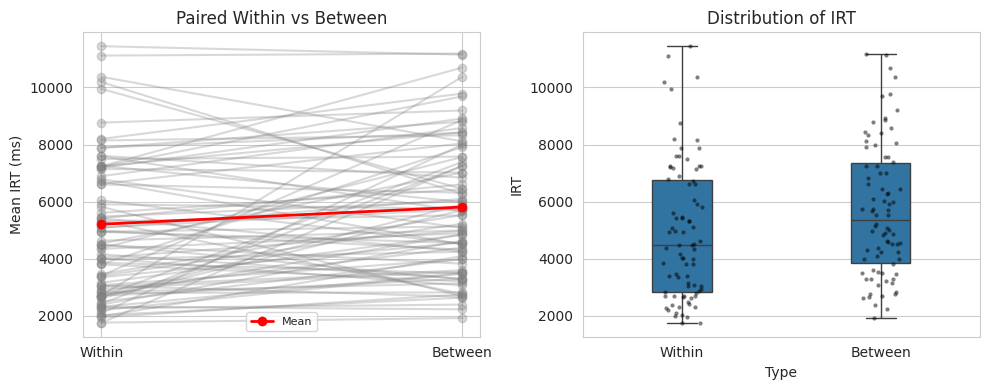

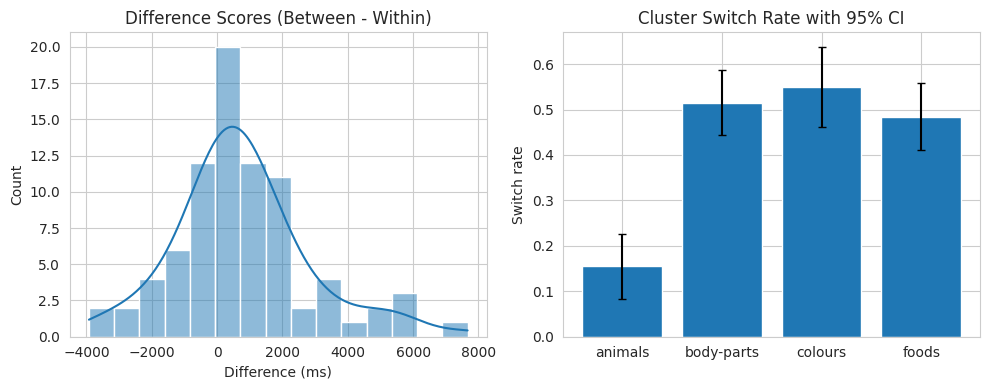

[OK] Part 2 complete. Figures saved in retrieval_time_analysis/ and cluster_analysis/
[OK] Intermediate file '_cluster_stats.csv' saved for Part 4.


In [63]:

print("\n" + "="*50)
print("Analysis 3: Semantic Clustering")
print("="*50)

def compute_cluster_metrics(group):
    clusters = group["cluster_label"].tolist()
    irts     = group["IRT_ms"].tolist()
    within, between, switches = [], [], 0
    total_transitions = len(clusters) - 1
    if total_transitions == 0:
        return pd.Series({"within_mean": np.nan, "between_mean": np.nan,
                          "switch_rate": np.nan, "n_transitions": 0})
    for i in range(total_transitions):
        if clusters[i] == clusters[i + 1]:
            within.append(irts[i + 1])
        else:
            between.append(irts[i + 1])
            switches += 1
    return pd.Series({
        "within_mean":   np.mean(within)  if within  else np.nan,
        "between_mean":  np.mean(between) if between else np.nan,
        "switch_rate":   switches / total_transitions,
        "n_transitions": total_transitions
    })

cluster_stats = (
    vft.sort_values(["subject_id", "domain", "position"])
       .groupby(["subject_id", "domain"])
       .apply(compute_cluster_metrics)
       .reset_index()
)
cluster_stats = cluster_stats[cluster_stats["n_transitions"] > 0].copy()
cluster_stats["diff"] = cluster_stats["between_mean"] - cluster_stats["within_mean"]

# Summary stats on difference scores
diff_clean = cluster_stats["diff"].dropna()
diff_mean  = diff_clean.mean()
diff_sd    = diff_clean.std(ddof=1)
diff_sem   = diff_sd / np.sqrt(len(diff_clean))
print(f"Difference (between - within): mean={diff_mean:.2f} ms, SD={diff_sd:.2f}, SEM={diff_sem:.2f}")
print(f"95% CI = ({diff_mean - 1.96*diff_sem:.2f}, {diff_mean + 1.96*diff_sem:.2f})")

# Normality + significance test
if len(diff_clean) > 1:
    shapiro_stat, shapiro_p = stats.shapiro(diff_clean)
    print(f"Shapiro-Wilk: p = {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        t_stat, p_val = ttest_1samp(diff_clean, 0)
        print(f"One-sample t-test: t={t_stat:.3f}, p={p_val:.4f}")
    else:
        t_stat, p_val = wilcoxon(diff_clean)
        print(f"Wilcoxon signed-rank: statistic={t_stat:.3f}, p={p_val:.4f}")

# Switch rate per domain
switch_rate_domain = cluster_stats.groupby("domain").agg(
    mean_switch=("switch_rate", "mean"),
    sd_switch=("switch_rate", "std"),
    sem_switch=("switch_rate", "sem"),
    n=("switch_rate", "count")
).reset_index()
switch_rate_domain["ci_low"]  = switch_rate_domain["mean_switch"] - 1.96 * switch_rate_domain["sem_switch"]
switch_rate_domain["ci_high"] = switch_rate_domain["mean_switch"] + 1.96 * switch_rate_domain["sem_switch"]
print("\nSwitch rate per domain:")
display(switch_rate_domain[["domain", "mean_switch", "sem_switch", "n"]])

# Export for Part 4
cluster_stats.to_csv(os.path.join(OUTPUT_DIR, "_cluster_stats.csv"), index=False)

# Figure 1: Paired line plot + Raincloud plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for _, row in cluster_stats.iterrows():
    if pd.notna(row["within_mean"]) and pd.notna(row["between_mean"]):
        ax1.plot([0, 1], [row["within_mean"], row["between_mean"]],
                 'o-', color='gray', alpha=0.3)
ax1.plot([0, 1],
         [cluster_stats["within_mean"].mean(), cluster_stats["between_mean"].mean()],
         'ro-', linewidth=2, markersize=6, label="Mean")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Within", "Between"])
ax1.set_ylabel("Mean IRT (ms)")
ax1.set_title("Paired Within vs Between")
ax1.legend(fontsize=8)

df_long = pd.melt(
    cluster_stats[["within_mean", "between_mean"]].dropna(),
    var_name="Type", value_name="IRT"
)
df_long["Type"] = df_long["Type"].replace({"within_mean": "Within", "between_mean": "Between"})
sns.boxplot(data=df_long, x="Type", y="IRT", width=0.3, ax=ax2)
sns.stripplot(data=df_long, x="Type", y="IRT", color='black',
              alpha=0.5, jitter=True, size=3, ax=ax2)
ax2.set_title("Distribution of IRT")

plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_FOLDER, "paired_raincloud.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# Figure 2: Difference histogram + Switch rate bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(cluster_stats["diff"].dropna(), kde=True, bins=15, ax=ax1)
ax1.set_xlabel("Difference (ms)")
ax1.set_title("Difference Scores (Between - Within)")

ax2.bar(switch_rate_domain["domain"], switch_rate_domain["mean_switch"],
        yerr=1.96 * switch_rate_domain["sem_switch"], capsize=3)
ax2.set_ylabel("Switch rate")
ax2.set_title("Cluster Switch Rate with 95% CI")

plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_FOLDER, "diff_switch.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()

print("[OK] Part 2 complete. Figures saved in retrieval_time_analysis/ and cluster_analysis/")
print("[OK] Intermediate file '_cluster_stats.csv' saved for Part 4.")


In [64]:
!pip install adjusttext

[OK] SpAM distances loaded: 5247 rows
[OK] SpAM cleaned loaded:   993 rows

Analysis 4: Semantic Space
Normalized distance statistics per domain:


,domain,mean,std,median,iqr
0,animals,0.568927,0.254321,0.603885,0.319187
1,body-parts,0.490228,0.332461,0.537459,0.633791
2,colours,0.496121,0.266759,0.514309,0.392000
3,foods,0.375702,0.259127,0.353311,0.200296



Domains found (4): ['animals', 'body-parts', 'colours', 'foods']
Heatmaps — Domains 1–3:


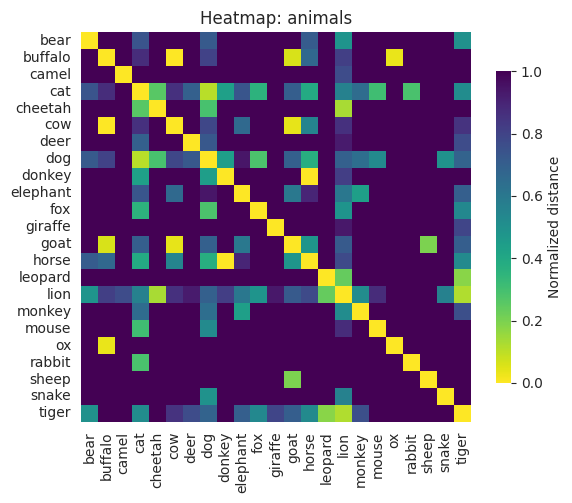

  [OK] heatmap_animals.png saved.


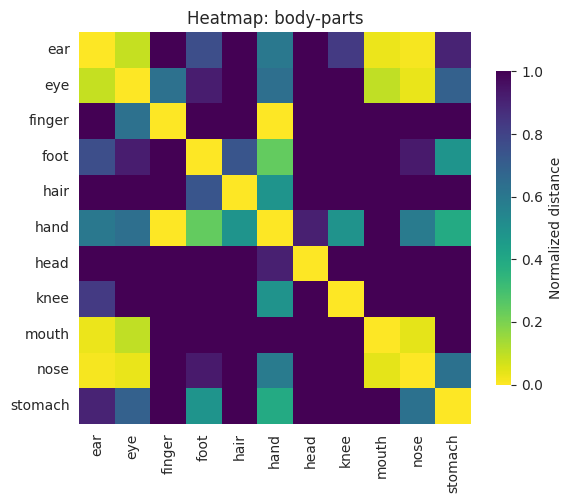

  [OK] heatmap_body-parts.png saved.


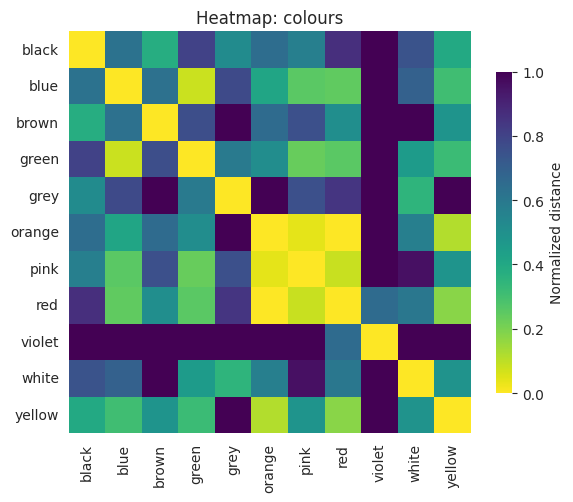

  [OK] heatmap_colours.png saved.
Heatmaps — Domains 4–6:


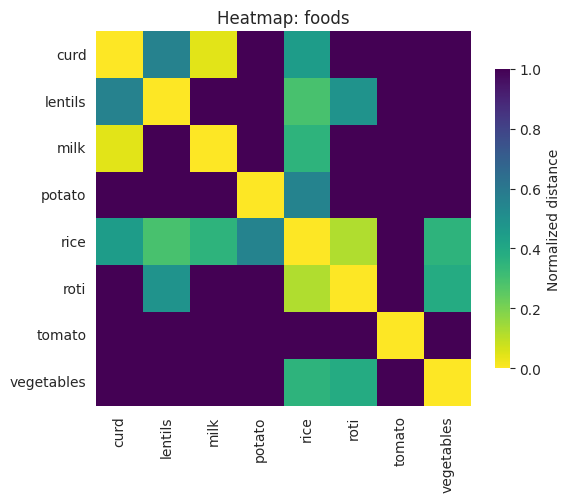

  [OK] heatmap_foods.png saved.
Scatter plots — all 6 domains:


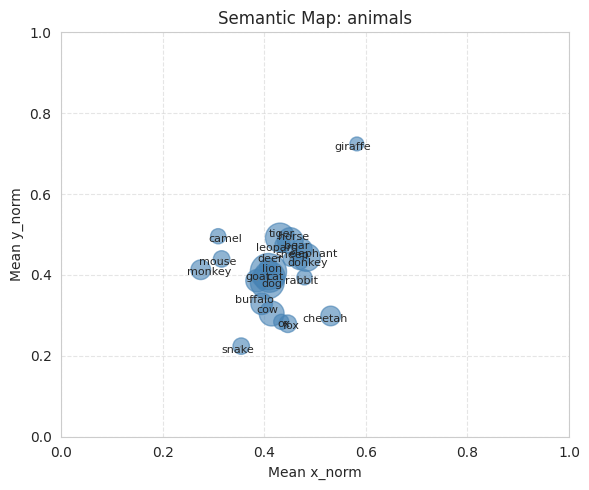

  [OK] scatter_animals.png saved.


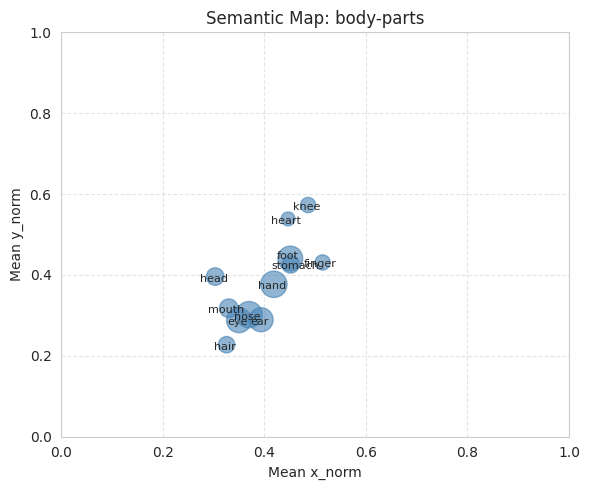

  [OK] scatter_body-parts.png saved.


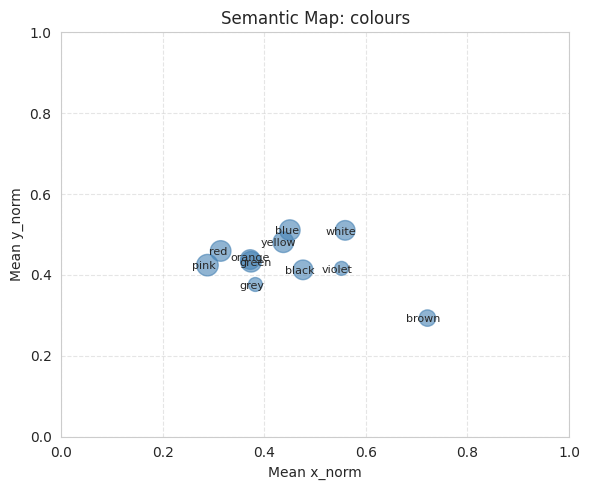

  [OK] scatter_colours.png saved.


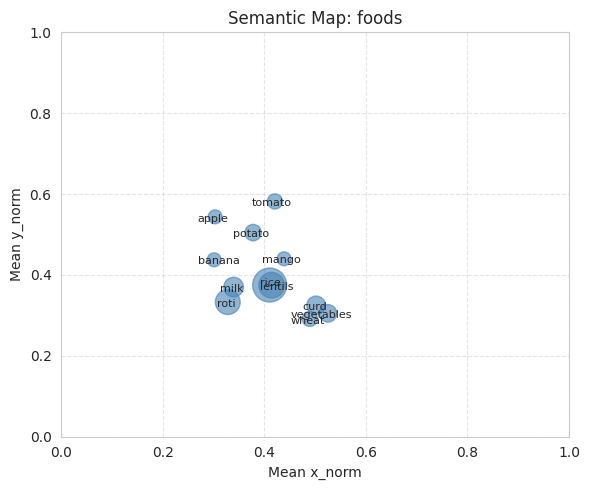

  [OK] scatter_foods.png saved.

[OK] Part 3 complete. 12 figures saved in semantic_space_analysis/


In [65]:


# This cell covers:
# - Analysis 4: Semantic space from SpAM


# %%
from adjustText import adjust_text


%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR  = "/content/cleaned_data"
OUTPUT_DIR = "/content/analysis_output"
# ─────────────────────────────────────────────────────────────────────────────

SEMANTIC_FOLDER = os.path.join(OUTPUT_DIR, "semantic_space_analysis")
os.makedirs(SEMANTIC_FOLDER, exist_ok=True)

spam_dist  = pd.read_csv(os.path.join(INPUT_DIR, "spam_distances.csv"))
spam_clean = pd.read_csv(os.path.join(INPUT_DIR, "spam_cleaned.csv"))
print(f"[OK] SpAM distances loaded: {len(spam_dist)} rows")
print(f"[OK] SpAM cleaned loaded:   {len(spam_clean)} rows")

#  Compute Word-Pair Stats & Normalize Distances

print("\n" + "="*50)
print("Analysis 4: Semantic Space")
print("="*50)

# Mean distance per word pair across participants (min 5 participants)
word_pair_stats = spam_dist.groupby(["domain", "word1", "word2"]).agg(
    mean_dist=("distance", "mean"),
    sd_dist=("distance", "std"),
    n=("distance", "count")
).reset_index()
word_pair_stats = word_pair_stats[word_pair_stats["n"] >= 5].copy()

# Normalize distances to [0, 1] per domain
for d in word_pair_stats["domain"].unique():
    mask  = word_pair_stats["domain"] == d
    min_d = word_pair_stats.loc[mask, "mean_dist"].min()
    max_d = word_pair_stats.loc[mask, "mean_dist"].max()
    if max_d > min_d:
        word_pair_stats.loc[mask, "norm_dist"] = (
            (word_pair_stats.loc[mask, "mean_dist"] - min_d) / (max_d - min_d)
        )
    else:
        word_pair_stats.loc[mask, "norm_dist"] = 0.5

# Descriptive stats of normalized distances per domain
dist_desc = word_pair_stats.groupby("domain")["norm_dist"].agg(
    mean="mean", std="std", median="median",
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
).reset_index()
print("Normalized distance statistics per domain:")
display(dist_desc)

# Mean coordinates per word (for scatter plots)
word_means = spam_clean.groupby(["domain", "word_canonical"]).agg(
    mean_x=("x_norm", "mean"),
    mean_y=("y_norm", "mean"),
    n=("x_norm", "count")
).reset_index()
word_means = word_means[word_means["n"] >= 5].copy()

domains = sorted(word_pair_stats["domain"].unique())
print(f"\nDomains found ({len(domains)}): {domains}")

# Heatmaps — Domains 1 to 3

def plot_heatmap(domain, word_pair_stats, out_folder):
    """Plot and save a normalized distance heatmap for one domain."""
    subset = word_pair_stats[word_pair_stats["domain"] == domain]
    words  = sorted(set(subset["word1"]).union(set(subset["word2"])))
    if len(words) < 2:
        print(f"  [Skip] {domain}: fewer than 2 words.")
        return
    n = len(words)
    mat = np.ones((n, n))
    for _, row in subset.iterrows():
        i, j = words.index(row["word1"]), words.index(row["word2"])
        mat[i, j] = mat[j, i] = row["norm_dist"]
    np.fill_diagonal(mat, 0)

    plt.figure(figsize=(6, 5))
    sns.heatmap(mat, xticklabels=words, yticklabels=words,
                cmap="viridis_r", square=True,
                cbar_kws={"label": "Normalized distance", "shrink": 0.8})
    plt.title(f"Heatmap: {domain}")
    plt.tight_layout()
    plt.savefig(os.path.join(out_folder, f"heatmap_{domain}.png"), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  [OK] heatmap_{domain}.png saved.")

print("Heatmaps — Domains 1–3:")
for d in domains[:3]:
    plot_heatmap(d, word_pair_stats, SEMANTIC_FOLDER)

#  Heatmaps — Domains 4 to 6


print("Heatmaps — Domains 4–6:")
for d in domains[3:]:
    plot_heatmap(d, word_pair_stats, SEMANTIC_FOLDER)

# ## Cell 5: Scatter Plots — Mean Word Coordinates per Domain (all 6 domains)

# %%
def plot_scatter(domain, word_means, out_folder):
    """Plot and save a semantic map scatter plot for one domain."""
    subset = word_means[word_means["domain"] == domain]
    if subset.empty:
        print(f"  [Skip] {domain}: no data.")
        return

    plt.figure(figsize=(6, 5))
    plt.scatter(subset["mean_x"], subset["mean_y"],
                s=subset["n"] * 20, alpha=0.6, c='steelblue')

    texts = [
        plt.text(row["mean_x"], row["mean_y"], row["word_canonical"],
                 fontsize=8, ha='center', va='center')
        for _, row in subset.iterrows()
    ]
    adjust_text(texts, expand_points=(1.2, 1.2), force_points=0.2,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel("Mean x_norm")
    plt.ylabel("Mean y_norm")
    plt.title(f"Semantic Map: {domain}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(out_folder, f"scatter_{domain}.png"), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  [OK] scatter_{domain}.png saved.")

print("Scatter plots — all 6 domains:")
for d in domains:
    plot_scatter(d, word_means, SEMANTIC_FOLDER)

print("\n[OK] Part 3 complete. 12 figures saved in semantic_space_analysis/")

[OK] Data loaded.
  VFT rows:           1020
  Demo rows:          35
  Stats1 rows:        105
  Cluster stats rows: 105

Analysis 5: Fluency Effects on Retrieval
Fluency dataset shape: (35, 8)


,subject_id,hindi_fluency_composite,hindi_read_fluency,hindi_write_fluency,hindi_confidence,total_words_all,mean_IRT_all,mean_switch_rate
0,10255,4.000000,4,4,4,49,2900.748980,0.400000
1,95712,4.666667,5,4,5,18,9028.333333,0.488889
2,53105,5.000000,5,5,5,21,7937.619048,0.400000
3,53307,4.000000,5,3,4,27,5875.359259,0.504762
4,92821,4.000000,4,4,4,52,3220.723077,0.380607


Correlation matrix:


,hindi_fluency_composite,total_words_all,mean_IRT_all,mean_switch_rate
hindi_fluency_composite,1.000000,-0.117719,0.304826,-0.262584
total_words_all,-0.117719,1.000000,-0.880055,-0.139274
mean_IRT_all,0.304826,-0.880055,1.000000,0.070490
mean_switch_rate,-0.262584,-0.139274,0.070490,1.000000


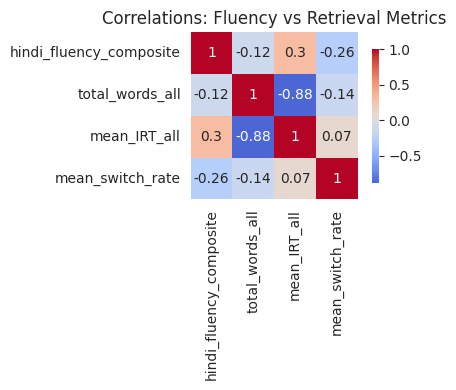

[OK] correlation_heatmap.png saved.


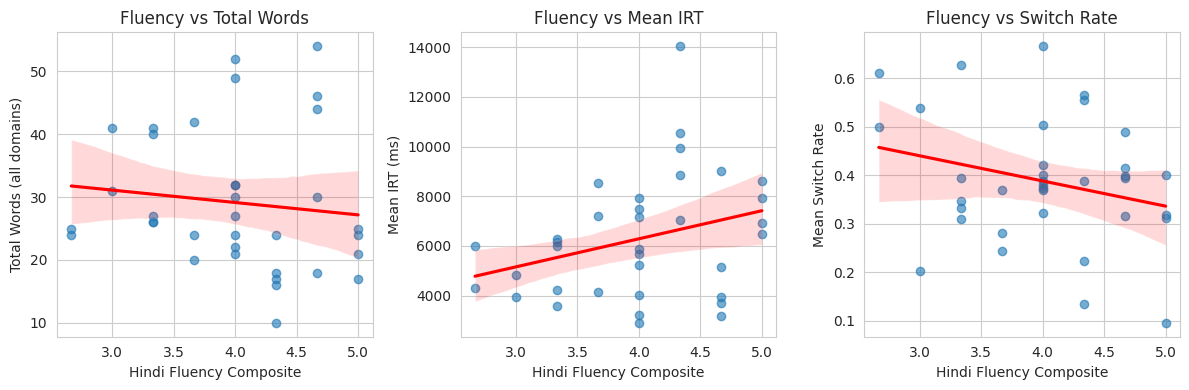

[OK] fluency_scatter_matrix.png saved.
Linear regression results (Hindi Fluency Composite vs each outcome):

Outcome: total_words_all
  slope=-1.970, intercept=37.02
  R²=0.014, p=0.5006

Outcome: mean_IRT_all
  slope=1130.147, intercept=1765.80
  R²=0.093, p=0.0750

Outcome: mean_switch_rate
  slope=-0.052, intercept=0.60
  R²=0.069, p=0.1275

[OK] Part 4 complete. Figures and tables saved in fluency_effects/
     - correlation_heatmap.png
     - fluency_scatter_matrix.png
     - fluency_correlations.csv
     - regression_results.txt


In [66]:

# # Report 1 — Part 4: Fluency Effects on Retrieval
#
# This notebook covers:
# - Analysis 5: Does Hindi fluency predict lexical retrieval efficiency?
# - Hypothesis: Higher Hindi fluency → more words, lower mean IRT, lower switch rate
#
# Requires intermediate files saved by Part 1 (_stats1_per_participant.csv)
# and Part 2 (_cluster_stats.csv).


# ## Cell 1: Imports & Setup


%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR  = "/content/cleaned_data"
OUTPUT_DIR = "/content/analysis_output"
# ─────────────────────────────────────────────────────────────────────────────

FLUENCY_FOLDER = os.path.join(OUTPUT_DIR, "fluency_effects")
os.makedirs(FLUENCY_FOLDER, exist_ok=True)

# Load cleaned data
vft           = pd.read_csv(os.path.join(INPUT_DIR, "vft_cleaned.csv"))
demo          = pd.read_csv(os.path.join(INPUT_DIR, "demographics_cleaned.csv"))

# Load intermediates from Part 1 and Part 2
stats1        = pd.read_csv(os.path.join(OUTPUT_DIR, "_stats1_per_participant.csv"))
cluster_stats = pd.read_csv(os.path.join(OUTPUT_DIR, "_cluster_stats.csv"))

print("[OK] Data loaded.")
print(f"  VFT rows:           {len(vft)}")
print(f"  Demo rows:          {len(demo)}")
print(f"  Stats1 rows:        {len(stats1)}")
print(f"  Cluster stats rows: {len(cluster_stats)}")


# Build Fluency Dataset

# %%
print("\n" + "="*50)
print("Analysis 5: Fluency Effects on Retrieval")
print("="*50)

# Composite Hindi fluency score (mean of read, write, confidence)
demo['hindi_read_fluency']    = pd.to_numeric(demo['hindi_read_fluency'],    errors='coerce')
demo['hindi_write_fluency']   = pd.to_numeric(demo['hindi_write_fluency'],   errors='coerce')
demo['hindi_confidence']      = pd.to_numeric(demo['hindi_confidence'],      errors='coerce')
demo['hindi_fluency_composite'] = demo[
    ['hindi_read_fluency', 'hindi_write_fluency', 'hindi_confidence']
].mean(axis=1, skipna=True)

demo_fluent = demo.dropna(subset=['hindi_fluency_composite']).copy()

# Aggregate retrieval measures per participant
words_per_subj  = stats1.groupby('subject_id')['total_words'].sum().reset_index(name='total_words_all')
irt_per_subj    = vft.groupby('subject_id')['IRT_ms'].mean().reset_index(name='mean_IRT_all')
switch_per_subj = cluster_stats.groupby('subject_id')['switch_rate'].mean().reset_index(name='mean_switch_rate')

# Merge everything
fluency_data = (
    demo_fluent[['subject_id', 'hindi_fluency_composite',
                 'hindi_read_fluency', 'hindi_write_fluency', 'hindi_confidence']]
    .merge(words_per_subj,  on='subject_id', how='inner')
    .merge(irt_per_subj,    on='subject_id', how='inner')
    .merge(switch_per_subj, on='subject_id', how='inner')
)

print(f"Fluency dataset shape: {fluency_data.shape}")
display(fluency_data.head())

# Correlation Matrix & Heatmap

# %%
corr_vars    = ['hindi_fluency_composite', 'total_words_all', 'mean_IRT_all', 'mean_switch_rate']
corr_matrix  = fluency_data[corr_vars].corr()
corr_matrix.to_csv(os.path.join(FLUENCY_FOLDER, "fluency_correlations.csv"))

print("Correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlations: Fluency vs Retrieval Metrics")
plt.tight_layout()
plt.savefig(os.path.join(FLUENCY_FOLDER, "correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] correlation_heatmap.png saved.")


#  Scatter Plots with Regression Lines

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.regplot(data=fluency_data, x='hindi_fluency_composite', y='total_words_all',
            ax=axes[0], scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[0].set_xlabel("Hindi Fluency Composite")
axes[0].set_ylabel("Total Words (all domains)")
axes[0].set_title("Fluency vs Total Words")

sns.regplot(data=fluency_data, x='hindi_fluency_composite', y='mean_IRT_all',
            ax=axes[1], scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[1].set_xlabel("Hindi Fluency Composite")
axes[1].set_ylabel("Mean IRT (ms)")
axes[1].set_title("Fluency vs Mean IRT")

sns.regplot(data=fluency_data, x='hindi_fluency_composite', y='mean_switch_rate',
            ax=axes[2], scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[2].set_xlabel("Hindi Fluency Composite")
axes[2].set_ylabel("Mean Switch Rate")
axes[2].set_title("Fluency vs Switch Rate")

plt.tight_layout()
plt.savefig(os.path.join(FLUENCY_FOLDER, "fluency_scatter_matrix.png"), dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("[OK] fluency_scatter_matrix.png saved.")

# ## Cell 5: Linear Regression Summaries & Export

outcomes = ['total_words_all', 'mean_IRT_all', 'mean_switch_rate']

print("Linear regression results (Hindi Fluency Composite vs each outcome):")
results_lines = [
    "Linear regression: Hindi Fluency Composite vs Retrieval Metrics",
    "=" * 60
]
for out in outcomes:
    slope, intercept, r_val, p_val, se = linregress(
        fluency_data['hindi_fluency_composite'], fluency_data[out]
    )
    line = (f"\nOutcome: {out}\n"
            f"  slope={slope:.3f}, intercept={intercept:.2f}\n"
            f"  R²={r_val**2:.3f}, p={p_val:.4f}")
    print(line)
    results_lines.append(line)

with open(os.path.join(FLUENCY_FOLDER, "regression_results.txt"), 'w') as f:
    f.write("\n".join(results_lines))

print("\n[OK] Part 4 complete. Figures and tables saved in fluency_effects/")
print("     - correlation_heatmap.png")
print("     - fluency_scatter_matrix.png")
print("     - fluency_correlations.csv")
print("     - regression_results.txt")